In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
testImage = cv2.imread('data/images/number_zero.jpg', 0)
testImage

array([[  1,   0,   3,   0,   3,   0,   3,   2,   4,   2,   0],
       [  0,   1,   0,   3,   3, 253, 253,   0,   0,   2,   1],
       [  0,   0,   8,   0, 249, 255, 255, 253,  71,   1,   5],
       [  3,   0,   2, 251, 255,   2,   0, 253, 254,   0,   2],
       [  1,   5,   0, 252,   4,   0,   3,   0, 255,   4,   0],
       [  0,   0,   2, 255,   0,   0,   0,   3, 253,   0,   4],
       [  0,   5,   4, 249,   4,   2,   0,   0, 255,   1,   0],
       [  2,   0,   0, 255,   3,   0,   5,   0, 254,   0,   4],
       [  0,   0,   0, 255,   1,   0,   0,   3, 255,   0,   0],
       [  1,   5,   0, 252,   2,   2,   2,  76, 250,   7,   0],
       [  0,   0,   5,   0, 254,   0,   0, 255, 254,   0,   1],
       [  0,   8,   0,   3, 253, 253, 255, 250,   1,   2,   1],
       [  2,   0,   0,   0,   5,   0,   4,   1,   3,   0,   0]],
      dtype=uint8)

In [3]:
print("Data type: {} \n".format(testImage.dtype))
print("Object type: {} \n".format(type(testImage)))
print("Image Dimensions: {} \n".format(testImage.shape))

Data type: uint8 

Object type: <class 'numpy.ndarray'> 

Image Dimensions: (13, 11) 



### Region of Interest

In [4]:
test_roi = testImage[0:5, 0:4]
print("Original Image:\n {} \n".format(testImage))
print("ROI Dimensions:\n {} \n".format(test_roi))

Original Image:
 [[  1   0   3   0   3   0   3   2   4   2   0]
 [  0   1   0   3   3 253 253   0   0   2   1]
 [  0   0   8   0 249 255 255 253  71   1   5]
 [  3   0   2 251 255   2   0 253 254   0   2]
 [  1   5   0 252   4   0   3   0 255   4   0]
 [  0   0   2 255   0   0   0   3 253   0   4]
 [  0   5   4 249   4   2   0   0 255   1   0]
 [  2   0   0 255   3   0   5   0 254   0   4]
 [  0   0   0 255   1   0   0   3 255   0   0]
 [  1   5   0 252   2   2   2  76 250   7   0]
 [  0   0   5   0 254   0   0 255 254   0   1]
 [  0   8   0   3 253 253 255 250   1   2   1]
 [  2   0   0   0   5   0   4   1   3   0   0]] 

ROI Dimensions:
 [[  1   0   3   0]
 [  0   1   0   3]
 [  0   0   8   0]
 [  3   0   2 251]
 [  1   5   0 252]] 



### CV2 utility functions

In [15]:
testImage2 = cv2.imread('data/images/musk.jpg', 1)
cv2.imshow('Musk', testImage2[:,:,:])
cv2.waitKey(0)
cv2.destroyAllWindows()

In [12]:
cv2.imwrite('data/images/musk_BRG.jpg', testImage2[:,:,::-1])

True

In [26]:
%cd data/images/
%pwd
%ls -l musk_BRG.jpg

[WinError 3] The system cannot find the path specified: 'data/images/'
f:\Opencv-Git\Learning-OpenCV\Week 1\data\images
 Volume in drive F is New Volume
 Volume Serial Number is 20BE-6474

 Directory of f:\Opencv-Git\Learning-OpenCV\Week 1\data\images


 Directory of f:\Opencv-Git\Learning-OpenCV\Week 1\data\images

02/01/2026  07:10 PM            59,682 musk_BRG.jpg
               1 File(s)         59,682 bytes
               0 Dir(s)  230,292,176,896 bytes free


Text(0.5, 1.0, 'Merged Image')

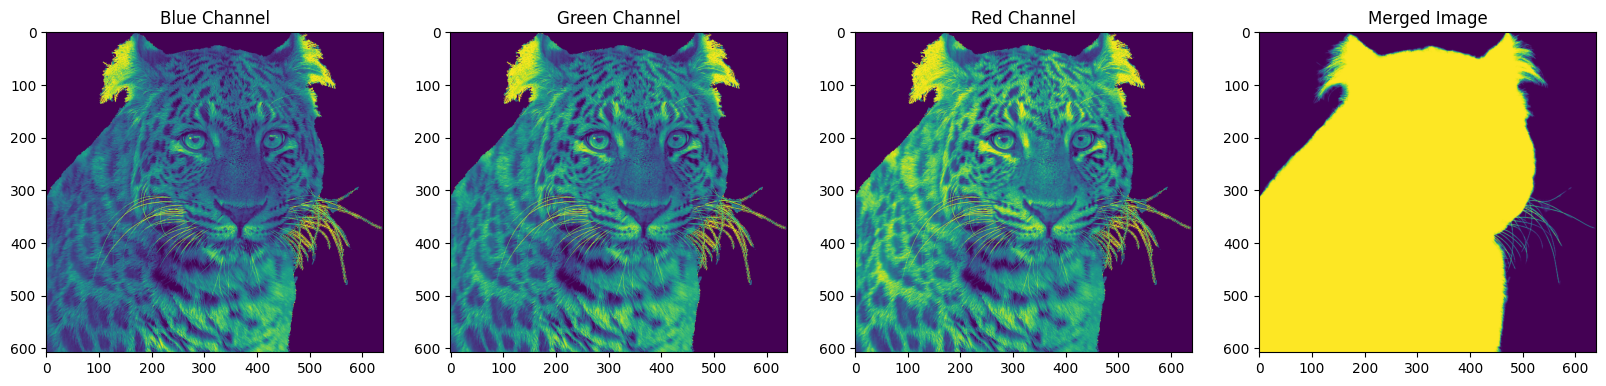

In [59]:
img = cv2.imread('panther.png', cv2.IMREAD_UNCHANGED)
plt.figure(figsize=[20,5])
plt.subplot(1, 4, 1); plt.imshow(img[:,:,0]); plt.title("Blue Channel")
plt.subplot(1, 4, 2); plt.imshow(img[:,:,1]); plt.title("Green Channel")
plt.subplot(1, 4, 3); plt.imshow(img[:,:,2]); plt.title("Red Channel")
plt.subplot(1, 4, 4); plt.imshow(img[:,:,3]); plt.title("Merged Image")

In [73]:
img1 = img.copy()
x = 255 * np.ones(img1.shape, dtype='uint8')

### Basic Image Operations

- Cropping

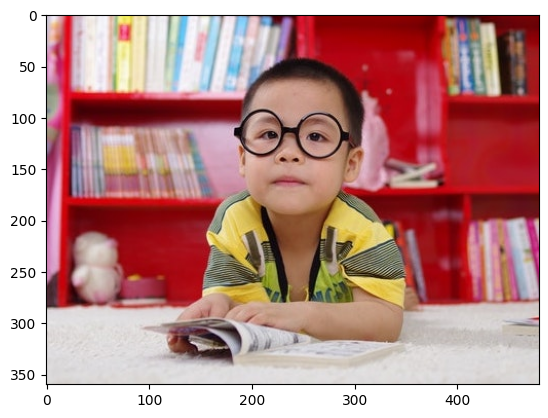

In [97]:
image = cv2.imread('boy.jpg', cv2.IMREAD_COLOR)
plt.imshow(image[:,:,::-1])


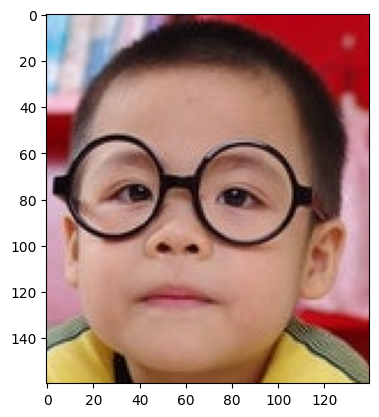

In [98]:
crop = image[40:200, 180:320]
plt.imshow(crop[...,::-1])

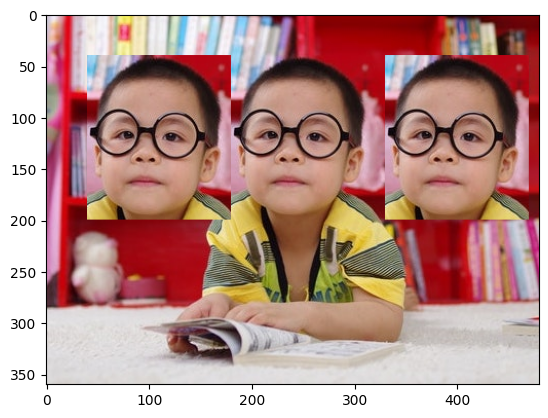

In [99]:
roi_height, roi_width = crop.shape[:2]
image[40:40+roi_height, 40:40+roi_width] = crop
image[40:40+roi_height, 2*roi_width+50:2*roi_width+50+roi_width] = crop
plt.imshow(image[:,:,::-1])

- Resizing

Text(0.5, 1.0, 'Scaled Down Image')

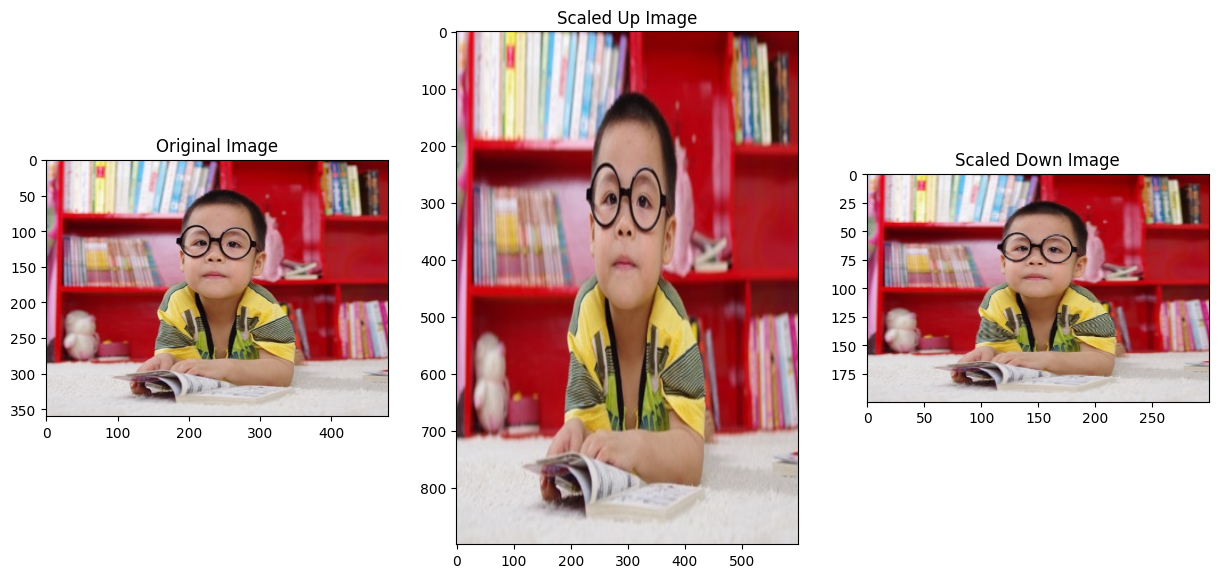

In [110]:
image = cv2.imread('boy.jpg', cv2.IMREAD_UNCHANGED)

# Set rows and columns
resizeDownWidth = 300
resizeDownHeight = 200
resizedDown = cv2.resize(image, (resizeDownWidth, resizeDownHeight), interpolation= cv2.INTER_LINEAR)

# Mess up with the aspect ratio
resizeUpWidth = 600
resizeUpHeight = 900
resizedUp = cv2.resize(image, (resizeUpWidth, resizeUpHeight), interpolation= cv2.INTER_LINEAR)

plt.figure(figsize=[15,15])
plt.subplot(131);plt.imshow(image[:,:,::-1]);plt.title("Original Image")
plt.subplot(132);plt.imshow(resizedUp[:,:,::-1]);plt.title("Scaled Up Image")
plt.subplot(133);plt.imshow(resizedDown[:,:,::-1]);plt.title("Scaled Down Image")

Text(0.5, 1.0, 'Scaled Down Image')

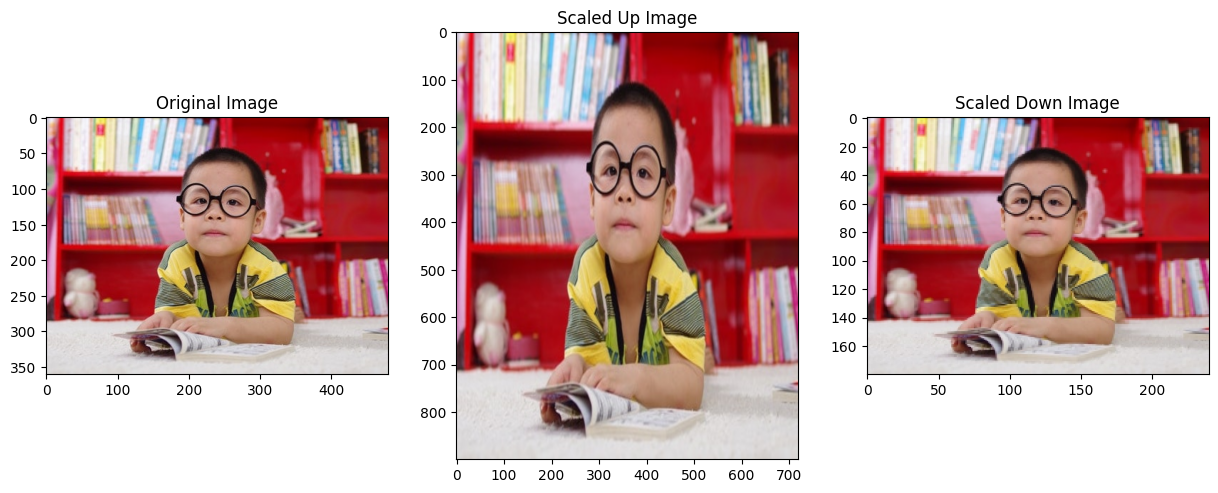

In [113]:
scaleUpx = 1.5
scaleUpy = 2.5
scaledUp = cv2.resize(image, None, fx=scaleUpx, fy=scaleUpy, interpolation=cv2.INTER_LINEAR)

scaleDown = 0.5
scaledDown = cv2.resize(image, None, fx=scaleDown, fy=scaleDown, interpolation=cv2.INTER_LINEAR)

plt.figure(figsize=[15,15])
plt.subplot(131);plt.imshow(image[:,:,::-1]);plt.title("Original Image")
plt.subplot(132);plt.imshow(scaledUp[:,:,::-1]);plt.title("Scaled Up Image")
plt.subplot(133);plt.imshow(scaledDown[:,:,::-1]);plt.title("Scaled Down Image")

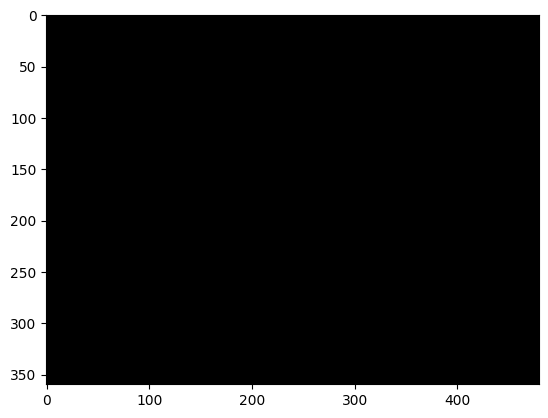

In [114]:
mask1 = np.zeros_like(image)
plt.imshow(mask1)

Text(0.5, 1.0, 'Mask Image')

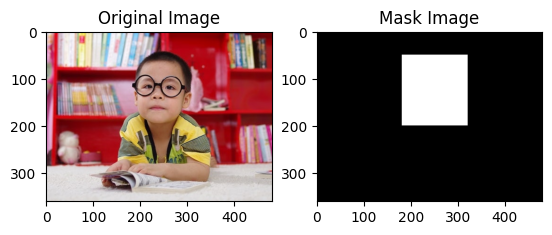

In [115]:
mask1[50:200, 180:320] = 255
plt.Figure(figsize=[10,10])
plt.subplot(121);plt.imshow(image[:,:,::-1]);plt.title("Original Image")
plt.subplot(122);plt.imshow(mask1[:,:,::-1]);plt.title("Mask Image")

Text(0.5, 1.0, 'Masked Image')

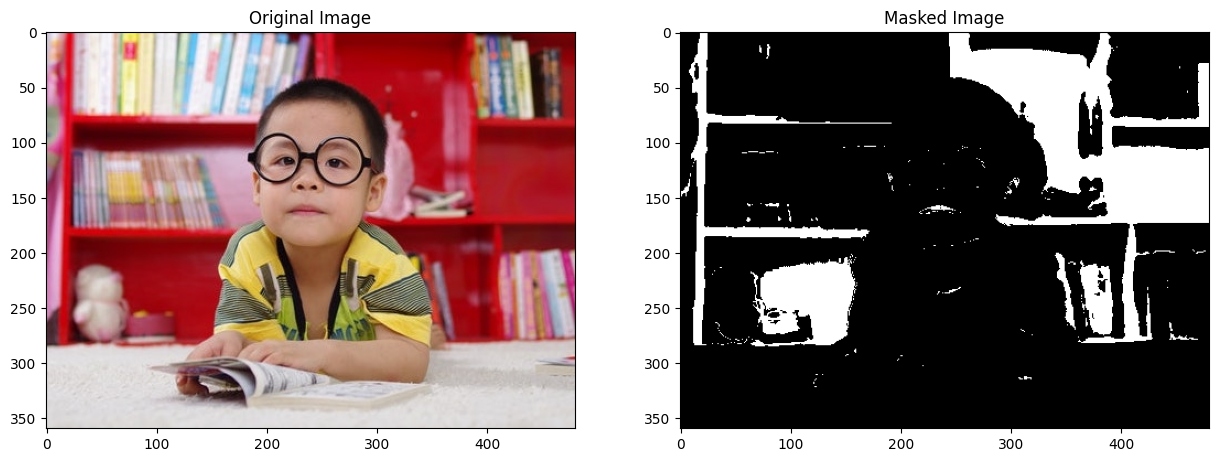

In [121]:
mask2 = cv2.inRange(image, (0,0,150), (100,100,255))
plt.figure(figsize=[15,15])
plt.subplot(121);plt.imshow(image[...,::-1]);plt.title("Original Image")
plt.subplot(122);plt.imshow(mask2, cmap='gray');plt.title("Masked Image")

### Mathematical Operations

- Datatype conversions
- Contrast  (I<sub>0</sub> = αI)
- Brightness  (I<sub>0</sub> = I + β)

In [2]:
import cv2
import numpy as np

image = cv2.imread('data/images/boy.jpg', 1)
print("Original image dtype: ", image.dtype)

image2 = np.float32(image) / 255.0  # We know uint8 ranges from 0 to 255 and to convert to float32 we need to scale it by 1/255
print("Converted image dtype: ", image2.dtype)

Original image dtype:  uint8
Converted image dtype:  float32


In [4]:
# to scale it back to uint8
image_back = np.uint8(image2 * 255.0)
image.dtype, image2.dtype, image_back.dtype

(dtype('uint8'), dtype('float32'), dtype('uint8'))

In [ ]:
# Contrast Enhancement

scalingFactor = 30.0  # 30% increase in contrast
contrastedImage = image * (1 + scalingFactor/100.0)
contrastedImage.dtype # since dtype got changed, we need to clip and convert it back to uint8(0,255)/float32(0,1) ranges

dtype('float64')

In [7]:
clippedImage = np.clip(contrastedImage, 0, 255)
finalUint8Image = np.uint8(clippedImage)

clippedToFloatImage = np.clip(contrastedImage / 255.0, 0, 1)


Text(0.5, 1.0, 'Contrasted Float32 Image')

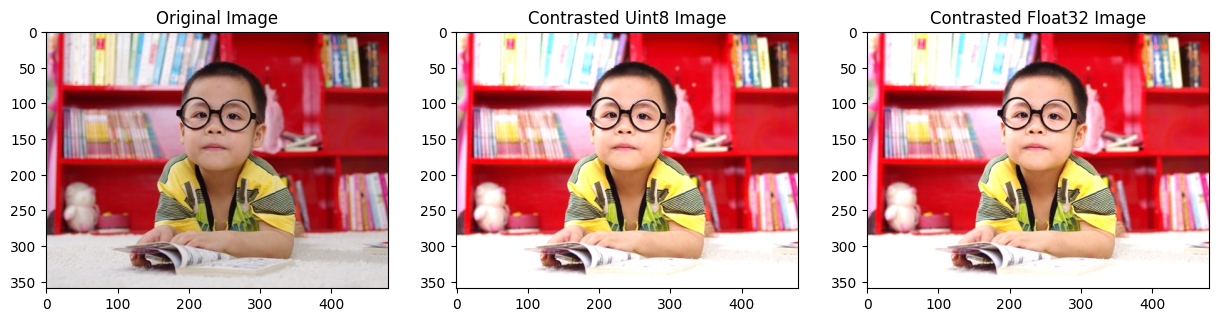

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=[15,10])
plt.subplot(131);plt.imshow(image[...,::-1]);plt.title("Original Image")
plt.subplot(132);plt.imshow(finalUint8Image[...,::-1]);plt.title("Contrasted Uint8 Image")
plt.subplot(133);plt.imshow(clippedToFloatImage[...,::-1]);plt.title("Contrasted Float32 Image")

Text(0.5, 1.0, 'Brightened Image')

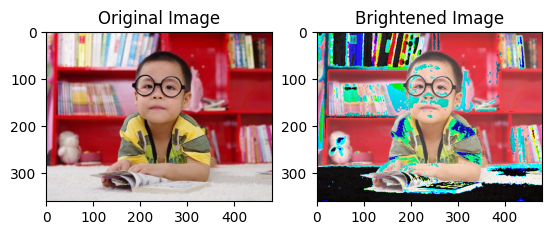

In [9]:
# Brightness Enhancement
brightnessOffset = 50  # 50% increase in brightness
brightnedImage = image + brightnessOffset

plt.Figure(figsize=[15,10])
plt.subplot(121);plt.imshow(image[...,::-1]);plt.title("Original Image")
plt.subplot(122);plt.imshow(brightnedImage[...,::-1]);plt.title("Brightened Image")

Text(0.5, 1.0, 'Brightened Image with Clipping')

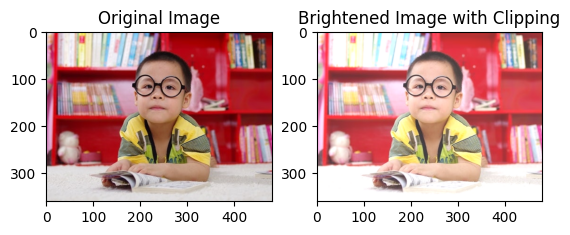

In [10]:
# Reason behind abnormality in the above image is due the individual pixel value exceeding 255, although the dtype is still uint8
# We need to clip the values to be in the range of 0-255 `cv2.add` function handles uint8 clipping

clippedBrightenedImage = cv2.add(image, brightnessOffset)
plt.Figure(figsize=[15,10])
plt.subplot(121);plt.imshow(image[...,::-1]);plt.title("Original Image")
plt.subplot(122);plt.imshow(clippedBrightenedImage[...,::-1]);plt.title("Brightened Image with Clipping")

### Application: Sunglass

#### Pseudo Code
1. first try to superimpose the entire image of glasses

Text(0.5, 1.0, 'Musk')

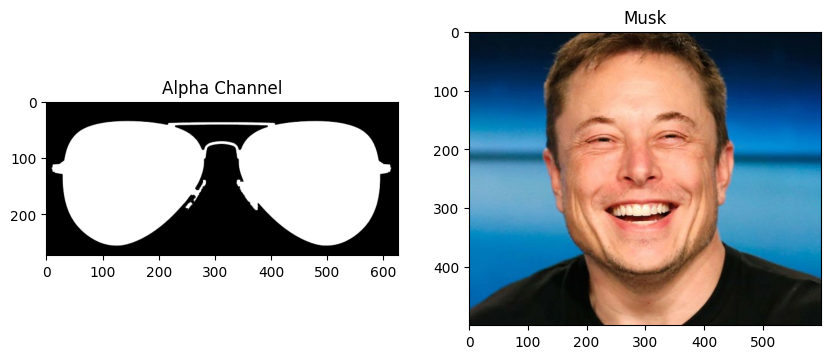

In [23]:
sunglasses = cv2.imread('data/images/sunglass.png', cv2.IMREAD_UNCHANGED)
musk = cv2.imread('data/images/musk.jpg', cv2.IMREAD_COLOR)

plt.figure(figsize=[10,10])
plt.subplot(121); plt.imshow(sunglasses[:,:,3], cmap='gray'); plt.title("Alpha Channel")
plt.subplot(122); plt.imshow(musk[...,::-1]); plt.title("Musk")

In [46]:
face = musk.copy()
resizedGlasses = cv2.resize(sunglasses, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_LINEAR)
glassBGR = resizedGlasses[...,:3]
glassMask = resizedGlasses[:,:,3]
# musk.shape, sunglasses.shape, face.shape

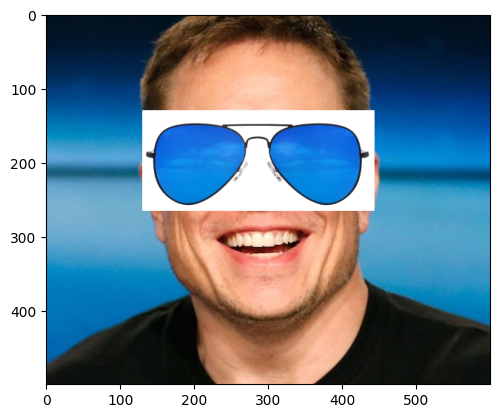

In [47]:
glassHeight, glassWidth, nChannels = resizedGlasses.shape

face[130: 130+glassHeight, 130: 130+glassWidth] = glassBGR
plt.imshow(face[...,::-1])

2. Using alpha channel as mask 

In [69]:
musk = cv2.imread('data/images/musk.jpg', cv2.IMREAD_UNCHANGED)
glasses = cv2.imread('data/images/sunglass.png', cv2.IMREAD_UNCHANGED)
musk = np.float32(musk)/255
glasses = np.float32(glasses)/255

# Resizing glasses
resizedGlasses = cv2.resize(glasses, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_LINEAR)
glassMask = resizedGlasses[:,:,3]
glassBGR = resizedGlasses[...,:3]

In [70]:
# Setting ROI
glassHeight, glassWidth, _ = resizedGlasses.shape

topLeftRow = 130
topLeftCol = 130
bottomRightRow = topLeftRow + glassHeight
bottomRightCol = topLeftCol + glassWidth

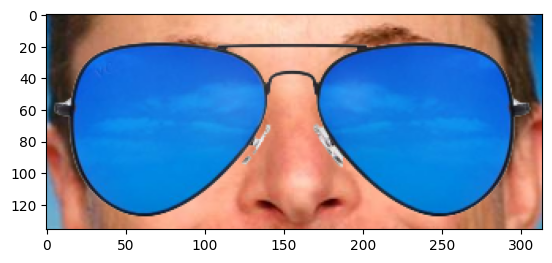

In [97]:
# copy of original image
face = musk.copy()
finalMask = cv2.merge((glassMask, glassMask, glassMask)) # creating 3 channels

eyeROI = face[topLeftRow:bottomRightRow,topLeftCol:bottomRightCol]
maskedEye = cv2.multiply(eyeROI, (1 - finalMask))
maskedGlass = cv2.multiply(glassBGR, finalMask)
finalROI = cv2.add(maskedEye, maskedGlass)
plt.imshow(finalROI[...,::-1])

Text(0.5, 1.0, 'Final Image with Glasses')

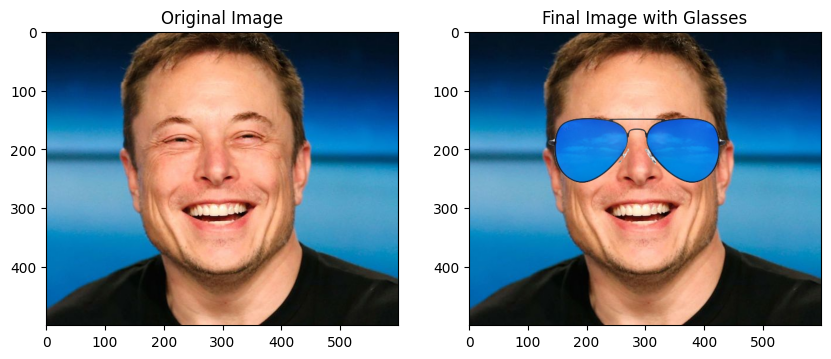

In [98]:
face[topLeftRow:bottomRightRow,topLeftCol:bottomRightCol]= finalROI

plt.figure(figsize=[10,10])
plt.subplot(121); plt.imshow(musk[...,::-1]); plt.title("Original Image")
plt.subplot(122); plt.imshow(face[...,::-1]); plt.title("Final Image with Glasses")


### Annotate Images

In [1]:
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

Text(0.5, 1.0, 'Drawing Line on a Image')

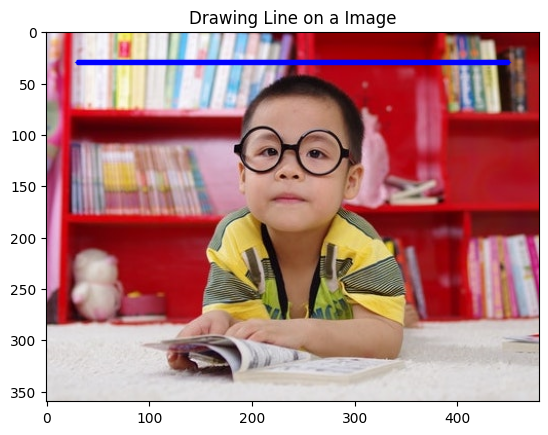

In [11]:
boy = cv2.imread('data/images/boy.jpg', 1)
copy1 = boy.copy()
# use ; to suppress the output of line function
cv2.line(copy1, (30, 30), (450, 30), (255,0,0), thickness=3, lineType=cv2.LINE_AA);

plt.imshow(copy1[:,:,::-1]); plt.title("Drawing Line on a Image")

Text(0.5, 1.0, 'Drawing Filled Circle on a Image')

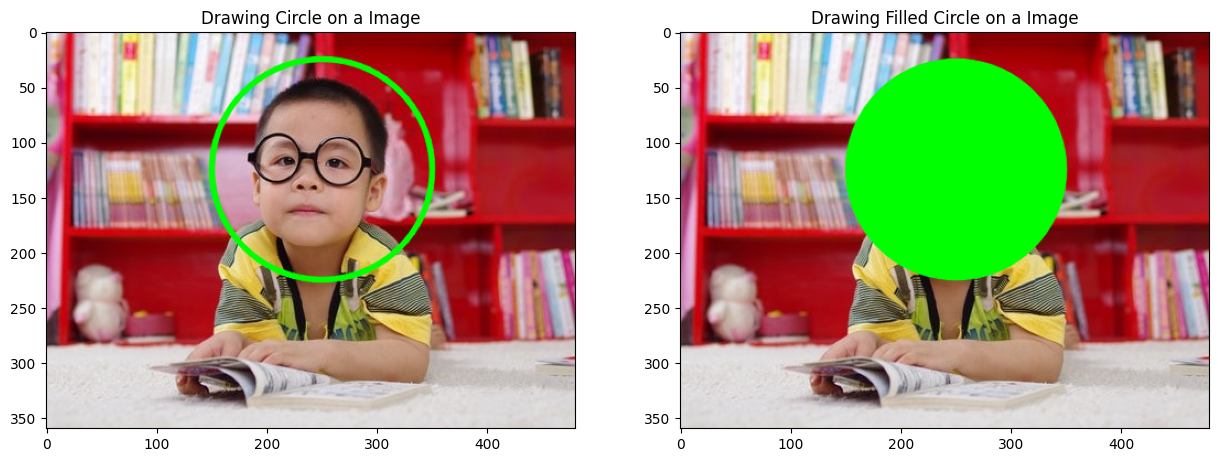

In [15]:
copy2 = boy.copy()
copy3 = boy.copy()

cv2.circle(copy2, (250, 125), 100, (0,255,0), thickness=3, lineType=cv2.LINE_AA)
cv2.circle(copy3, (250, 125), 100, (0,255,0), thickness=-1, lineType=cv2.LINE_AA)

plt.figure(figsize=[15,10])

plt.subplot(121);plt.imshow(copy2[...,::-1]); plt.title("Drawing Circle on a Image")
plt.subplot(122);plt.imshow(copy3[...,::-1]); plt.title("Drawing Filled Circle on a Image")

Text(0.5, 1.0, 'Drawing Ellipse on a Image')

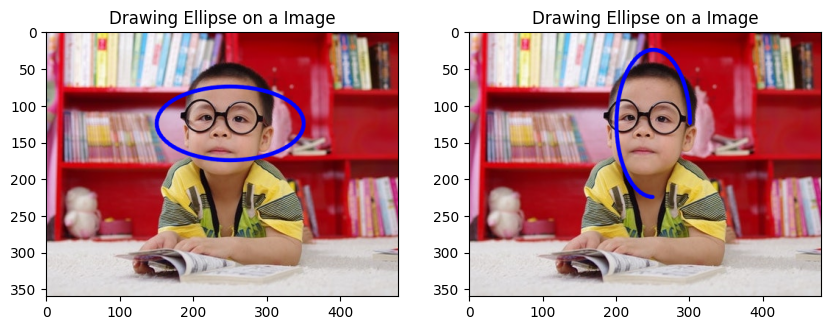

In [22]:
copy4 = boy.copy()
copy5 = boy.copy()

cv2.ellipse(copy4, (250, 125), (100, 50), 0, 0, 360, (255, 0, 0), thickness=3, lineType=cv2.LINE_AA)
cv2.ellipse(copy5, (250, 125), (100, 50), 90, 0, 270, (255, 0, 0), thickness=3, lineType=cv2.LINE_AA)

plt.figure(figsize=[10,10])
plt.subplot(121);plt.imshow(copy4[...,::-1]); plt.title("Drawing Ellipse on a Image")
plt.subplot(122);plt.imshow(copy5[...,::-1]); plt.title("Drawing Ellipse on a Image")

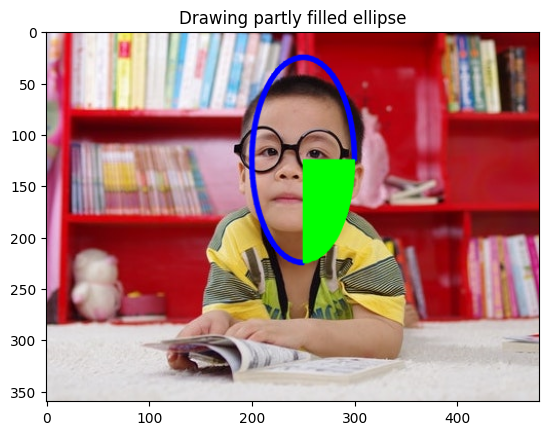

In [23]:
cv2.ellipse(copy5, (250, 125), (100, 50), 90, 270, 360, (0, 255, 0), thickness=-1, lineType=cv2.LINE_AA)

plt.imshow(copy5[...,::-1]); plt.title("Drawing partly filled ellipse");

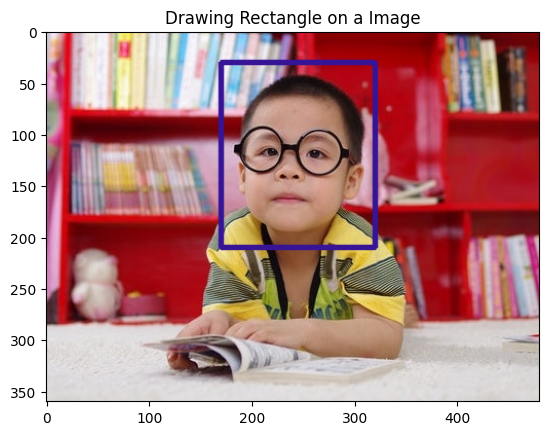

In [47]:
copy6 = boy.copy()

cv2.rectangle(copy6, (170, 30), (320, 210), (150, 20, 55), thickness=3, lineType=cv2.LINE_AA);

plt.imshow(copy6[...,::-1]); plt.title("Drawing Rectangle on a Image");

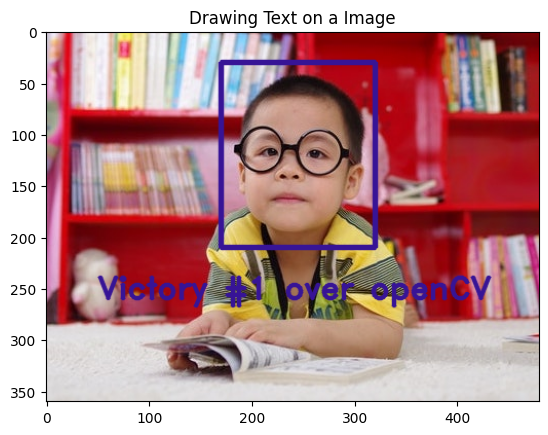

In [48]:
text = "Victory #1 over openCV"
fontScale = 1
fontFace = cv2.FONT_HERSHEY_DUPLEX
fontColor = (150, 20, 55)
fontThickness = 2

cv2.putText(copy6, text, (50, 260), fontFace, fontScale, fontColor, fontThickness, lineType=cv2.LINE_AA);

plt.imshow(copy6[:,:,::-1]); plt.title("Drawing Text on a Image");

 TextWidth: 385, TextHeight: 22, BaseLine: 10
TextBox's bottom-left coordinate: (47, 340)
Canvas bottom-left: (47, 350), top-right: (432, 308)


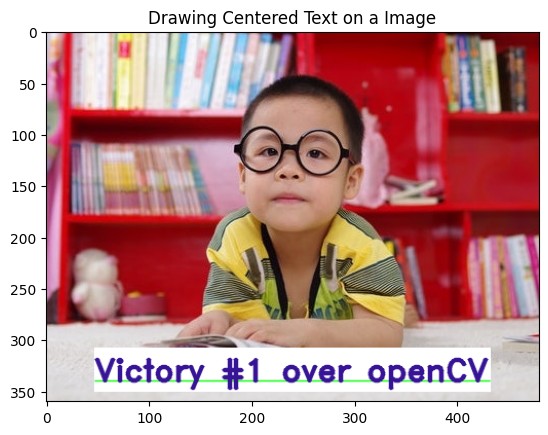

In [55]:
copy7 = boy.copy()

pixelHeight = 20

imageHeight, imageWidth = copy7.shape[:2]

textSize, baseLine = cv2.getTextSize(text, fontFace, fontScale, fontThickness)
textWidth, textHeight = textSize
print(" TextWidth: {}, TextHeight: {}, BaseLine: {}".format(textWidth, textHeight, baseLine))

xcoordinate = (imageWidth - textWidth) // 2
ycoordinate = (imageHeight - baseLine - 10)
print("TextBox's bottom-left coordinate: ({}, {})".format(xcoordinate, ycoordinate))

canvasColor = (255, 255, 255)
canvasBottomLeft = (xcoordinate, ycoordinate + baseLine)
canvasTopRight = (xcoordinate + textWidth, ycoordinate - textHeight -10)
cv2.rectangle(copy7, canvasBottomLeft, canvasTopRight, canvasColor, thickness=-1);

print("Canvas bottom-left: {}, top-right: {}".format(canvasBottomLeft, canvasTopRight))

linethickness = 1
lineLeft = (xcoordinate, ycoordinate)
lineRight = (xcoordinate + textWidth, ycoordinate)
lineColor = (0, 255, 0)
cv2.line(copy7, lineLeft, lineRight, lineColor, thickness=linethickness, lineType=cv2.LINE_AA);

cv2.putText(copy7, text, (xcoordinate, ycoordinate), fontFace, fontScale, fontColor, fontThickness, cv2.LINE_AA);

plt.imshow(copy7[:,:,::-1]); plt.title("Drawing Centered Text on a Image");